In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('Customer Data.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

I will drop CUST_ID which does not bring any meaning. 

In [4]:
df =df.drop(columns=['CUST_ID'])

In [5]:
df.dtypes

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [ ]:
df.isna().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [7]:
#Fill missing values
df['MINIMUM_PAYMENTS']=df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean())
df['CREDIT_LIMIT']=df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())

In [8]:
df.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [9]:
print(df.duplicated().sum())

0


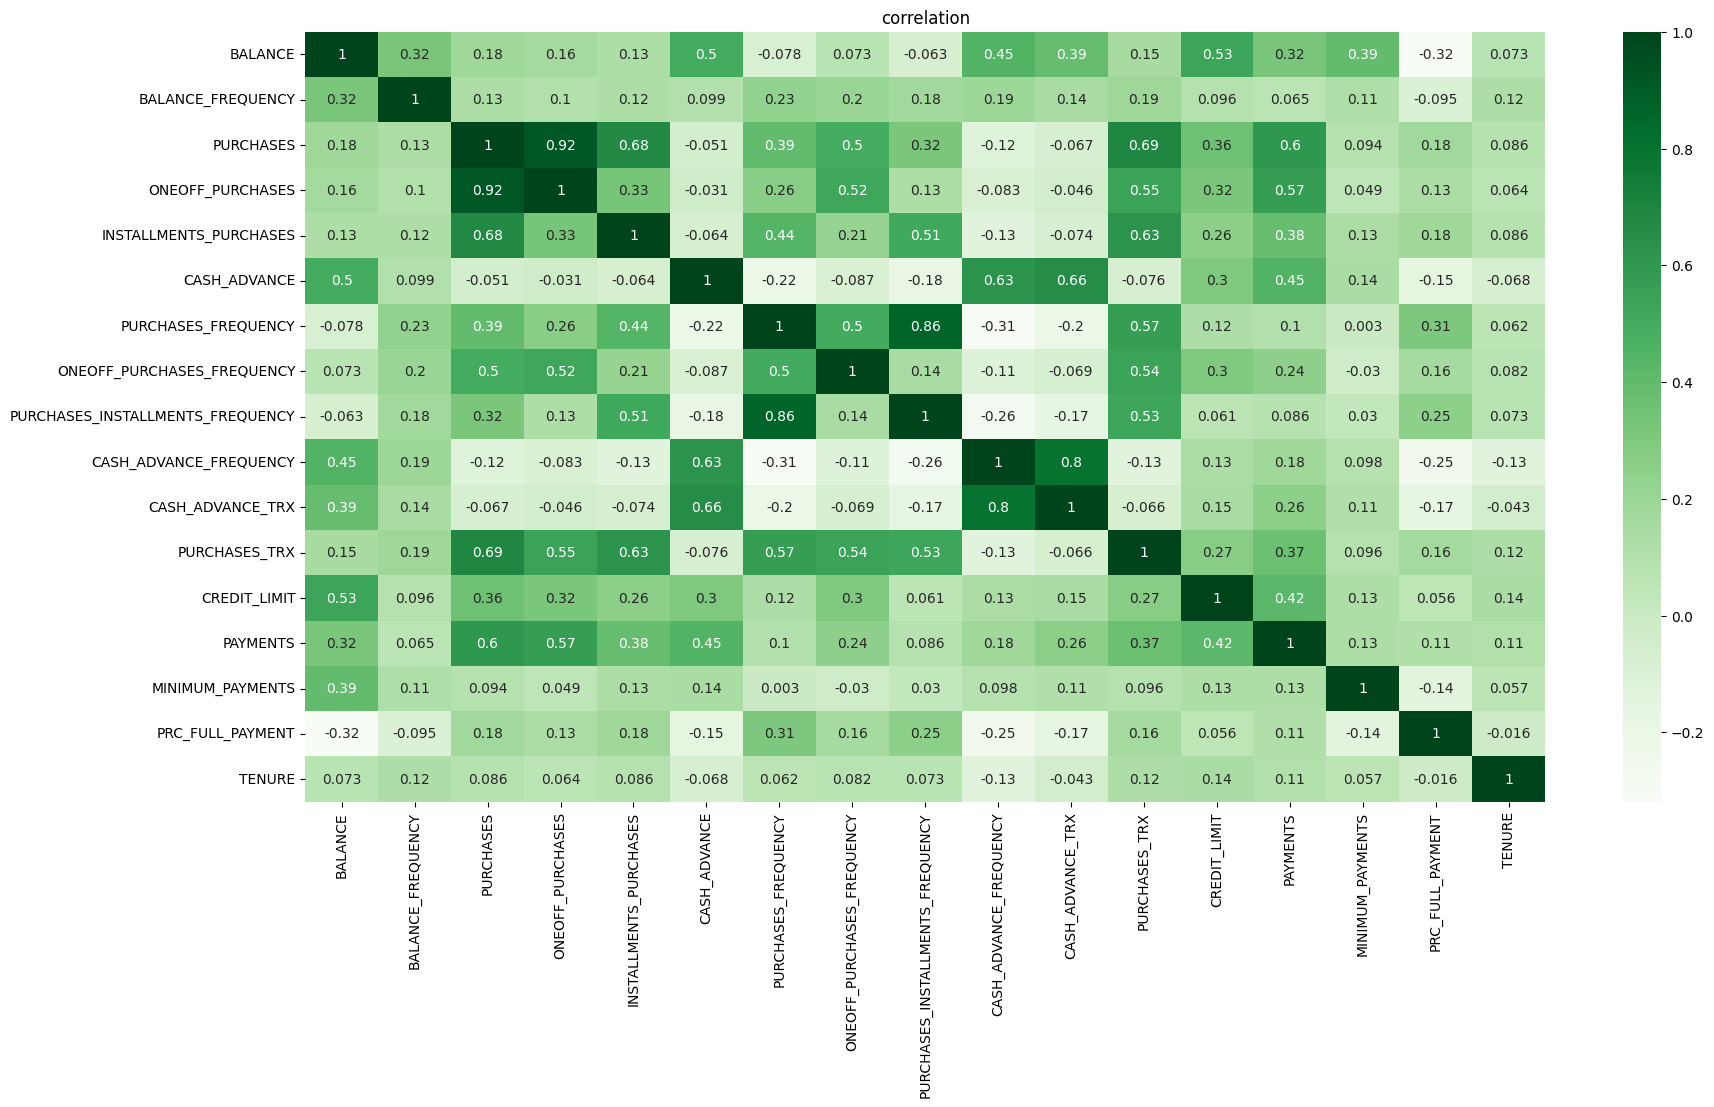

In [10]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr() ,  annot=True, cmap="Greens")
plt.title('correlation')
plt.show()

Even some variables like ONEOFF_PURCHASES. PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_TRX were highly correlated, removing them did not improve the silhouette score or clustering quality. Therefore, I leave all original features to preserve full customer behavior information. 

# Feature Engineeering
Original variables were grouped into behavioral categories such as purchases, cash advances, credit usage, and payment behavior to reduce dimensionality and improve interpretability while retaining essential information. After careful review of the dataset, I can group them into 6 main categories with 10 features for better analysis.

In [11]:
df_grouped = pd.DataFrame()
#1.Balance Info
df_grouped['Balance_Info'] = df['BALANCE'] * df['BALANCE_FREQUENCY']
#2.Purchases
df_grouped['Purchases'] = (df['PURCHASES']+df['ONEOFF_PURCHASES']+df['INSTALLMENTS_PURCHASES'])
df_grouped['Purchases_Frequency'] = (df['PURCHASES_FREQUENCY']+df['ONEOFF_PURCHASES_FREQUENCY']+df['PURCHASES_INSTALLMENTS_FREQUENCY'])
df_grouped['Purchases_TRX'] = df['PURCHASES_TRX']
#3.Cash Advance
df_grouped['Cash_Advance'] = df['CASH_ADVANCE']
df_grouped['Cash_Advance_Frequency'] = df['CASH_ADVANCE_FREQUENCY']
df_grouped['Cash_Advance_TRX'] = df['CASH_ADVANCE_TRX']
#4.Credit & Payments
df_grouped['Credit_Info'] = df['CREDIT_LIMIT']+df['PAYMENTS']+df['MINIMUM_PAYMENTS']
#5.Full Payment
df_grouped['Full_Payment_Ratio'] = df['PRC_FULL_PAYMENT']
#6.Tenure
df_grouped['Tenure'] = df['TENURE']

df_grouped.head()

,Balance_Info,Purchases,Purchases_Frequency,Purchases_TRX,Cash_Advance,Cash_Advance_Frequency,Cash_Advance_TRX,Credit_Info,Full_Payment_Ratio,Tenure
0,33.464257,190.80,0.250000,2,0.000000,0.000000,0,1341.311871,0.000000,12
1,2911.334306,0.00,0.000000,0,6442.945483,0.250000,4,12175.372814,0.222222,12
2,2495.148862,1546.34,2.000000,12,0.000000,0.000000,0,8749.351529,0.000000,12
3,1060.609133,2998.00,0.166666,1,205.788017,0.083333,1,8364.206542,0.000000,12
4,817.714335,32.00,0.166666,1,0.000000,0.000000,0,2123.126000,0.000000,12


In [13]:
df_grouped.isna().sum()

Balance_Info              0
Purchases                 0
Purchases_Frequency       0
Purchases_TRX             0
Cash_Advance              0
Cash_Advance_Frequency    0
Cash_Advance_TRX          0
Credit_Info               0
Full_Payment_Ratio        0
Tenure                    0
dtype: int64

# Scaling 

This is to segment credit card customers into distinct groups based on their spending behavior, credit usage, and payment patterns, so that the bank can better understand different customer profiles. 

In [14]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_grouped)

In [15]:
kmean = KMeans(n_clusters=3, random_state=42)
kmean.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [16]:
#Cluster assignments for each customer
kmean.labels_

array([1, 0, 1, ..., 1, 1, 1], shape=(8950,), dtype=int32)

In [17]:
#Add cluster labels to original dataframe['cluster']=kmean.labels_
df_grouped['Cluster']=kmean.labels_
df_grouped.head()

,Balance_Info,Purchases,Purchases_Frequency,Purchases_TRX,Cash_Advance,Cash_Advance_Frequency,Cash_Advance_TRX,Credit_Info,Full_Payment_Ratio,Tenure,Cluster
0,33.464257,190.80,0.250000,2,0.000000,0.000000,0,1341.311871,0.000000,12,1
1,2911.334306,0.00,0.000000,0,6442.945483,0.250000,4,12175.372814,0.222222,12,0
2,2495.148862,1546.34,2.000000,12,0.000000,0.000000,0,8749.351529,0.000000,12,1
3,1060.609133,2998.00,0.166666,1,205.788017,0.083333,1,8364.206542,0.000000,12,1
4,817.714335,32.00,0.166666,1,0.000000,0.000000,0,2123.126000,0.000000,12,1


In [18]:
#View customers in cluster 1
df_grouped[df_grouped.Cluster==1]

,Balance_Info,Purchases,Purchases_Frequency,Purchases_TRX,Cash_Advance,Cash_Advance_Frequency,Cash_Advance_TRX,Credit_Info,Full_Payment_Ratio,Tenure,Cluster
0,33.464257,190.80,0.250000,2,0.000000,0.000000,0,1341.311871,0.00,12,1
2,2495.148862,1546.34,2.000000,12,0.000000,0.000000,0,8749.351529,0.00,12,1
3,1060.609133,2998.00,0.166666,1,205.788017,0.083333,1,8364.206542,0.00,12,1
4,817.714335,32.00,0.166666,1,0.000000,0.000000,0,2123.126000,0.00,12,1
5,1809.828751,2666.56,1.250000,8,0.000000,0.000000,0,5607.303805,0.00,12,1
...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,582.24,1.833333,6,0.000000,0.000000,0,1374.480827,0.50,6,1
8946,19.183215,600.00,1.833333,6,0.000000,0.000000,0,2140.067864,0.00,6,1
8947,19.498886,288.80,1.500000,5,0.000000,0.000000,0,1163.689144,0.25,6,1
8948,11.214632,0.00,0.000000,0,36.558778,0.166667,2,608.305587,0.25,6,1


In [19]:
#Cluster centers in original feature
kmean.cluster_centers_

array([[ 1.33002538, -0.18624691, -0.44829636, -0.22956483,  1.60234039,
         1.73235819,  1.5697803 ,  0.86081765, -0.40093367, -0.12935103],
       [-0.28968617, -0.28628196, -0.33955788, -0.33778742, -0.24684313,
        -0.22428545, -0.23553327, -0.38149052, -0.26161971, -0.05182711],
       [-0.09796719,  0.85066245,  1.15253697,  1.00990033, -0.37960816,
        -0.5194615 , -0.388011  ,  0.43336135,  0.92306019,  0.21438127]])

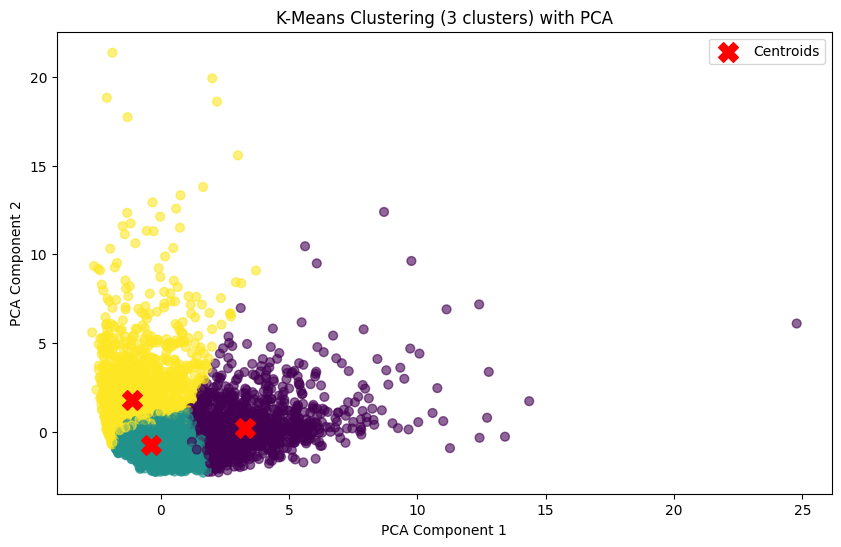

In [20]:
#Reduce data to 2D for visualization using PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=["PCA1","PCA2"])
pca_df['Cluster'] = kmean.labels_

#Transform cluster centers to PCA space
centroids_pca = pca.transform(kmean.cluster_centers_)

plt.figure(figsize=(10,6))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=pca_df['Cluster'], cmap='viridis', s=40, alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title("K-Means Clustering (3 clusters) with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

The PCA visualization shows clear separation between the three clusters, indicating that the clustering model successfully grouped customers with similar financial behavior

In [21]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
wcss

[89500.0,
 71476.72855697537,
 60301.04361842591,
 52557.63174955635,
 48765.69581197173,
 43559.61686274283,
 37801.63624224209,
 35568.39898102475,
 34029.72891360508,
 31342.450722181864]

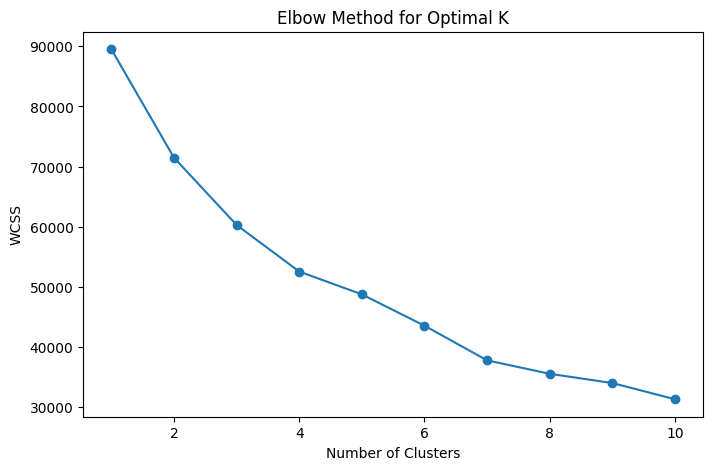

In [22]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

The elbow point represents the number of clusters after which adding more clusters does not significantly reduce the within-cluster sum of squares.

# Silhouette analysis to evaluate clustering quality

In [23]:
from sklearn.metrics import silhouette_score
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
sil_scores

[0.3690191482555763,
 0.2728947072720577,
 0.2227420347854395,
 0.205110053788215,
 0.23307017858182713,
 0.2696492317003574,
 0.2702993089002792,
 0.2602652703731953,
 0.2627717830794956]

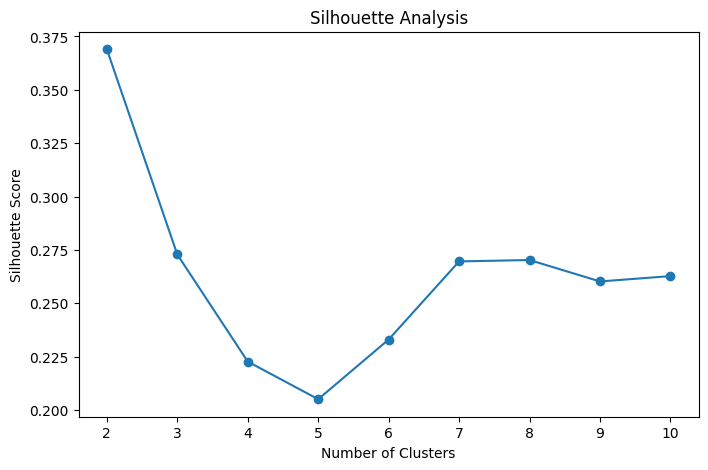

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Even though the silhouette score is highest for K = 2, using only two clusters would oversimplify credit card transactions and financial behavior. By choosing K = 3, it capture three meaningful segments: low, medium, and high spenders. This provides more actionable insights into spending patterns, credit usage, and payment behavior. K = 3 balances cluster quality with practical business value. 

In [25]:
#Save the model and scaler
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmean, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)